# Correccion de la matriz de confusion — Regresion NO espacializada

**Por que existe este notebook:** en `03_regresion_no_espacial_raster.ipynb` el AUC-ROC
y las curvas ya estan calculadas correctamente tomando **Altiplano (1)** como la clase
positiva (se verifico explicitamente el comportamiento de `predict_proba`/`roc_curve` de
sklearn). El problema NO es de calculo sino de **visualizacion**: la figura
`13_matriz_confusion_roc.png` colorea la matriz de confusion por el conteo bruto de cada
celda (`ConfusionMatrixDisplay` con cmap `Blues`). Como el 85% de los pixeles son
"No altiplano", la celda de aciertos de "No altiplano" (73,359) sale casi negra y domina
visualmente, mientras que la celda que importa para este trabajo — aciertos de
**Altiplano** (8,754) — casi no se distingue del fondo blanco. Es decir, la figura hace
parecer que el resultado protagonico es sobre "No altiplano" en vez de sobre Altiplano.

**Correccion aplicada:** se reproduce el mismo pipeline de datos, muestreo y modelo del
notebook 03 (misma `SEMILLA=42`, mismo `N_MUESTRA=300_000`, mismo split 70/30) para llegar
exactamente a las mismas predicciones, y se reemplaza la figura de matriz de
confusion + ROC por una figura de **3 paneles**:
1. Matriz de confusion con conteos brutos (igual que antes, como referencia).
2. Matriz de confusion **normalizada por fila** (por clase real): cada clase se colorea en
   su propia escala 0-1, asi el recall de Altiplano se ve con el mismo peso visual que el
   de "No altiplano", sin quedar opacado por el desbalance de conteos.
3. Curva ROC (igual que antes, AUC = 0.952 — ya correcta, se mantiene sin cambios).

**Este notebook NO modifica `03_regresion_no_espacial_raster.ipynb`.** Solo reproduce lo
necesario para regenerar la figura corregida y la exporta a la carpeta `Imagenes`.

## [1] Configuracion e importacion de librerias

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix, roc_curve, roc_auc_score, accuracy_score,
)

warnings.filterwarnings("ignore")

CARPETA_RASTER = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Raster\50m_UTM\Analisis"
CARPETA_IMAGENES = r"C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Imagenes"

SEMILLA = 42
N_MUESTRA = 300_000

t_inicio = time.time()

## [2] Reproducir el pipeline de datos del notebook 03

Mismos pasos: DEM como grilla de referencia, alineacion de `Altiplanos.tif`, mascara de
validez combinada con los 18 predictores, y tabla de pixeles. Se omiten aqui las celdas de
diagnostico (VIF, correlacion) del notebook original porque no son necesarias para
reproducir el modelo de clasificacion.

In [2]:
with rasterio.open(f"{CARPETA_RASTER}\\DEM_NA_50.tif") as src:
    altitud = src.read(1).astype(np.float32)
    dem_nodata = src.nodata
    ref_transform = src.transform
    ref_crs = src.crs
    ref_shape = (src.height, src.width)

mascara_dem_valida = altitud != dem_nodata

with rasterio.open(f"{CARPETA_RASTER}\\Altiplanos.tif") as src:
    altiplano_original = src.read(1)
    altiplano_nodata = src.nodata
    altiplano_transform = src.transform
    altiplano_crs = src.crs

altiplano_alineado = np.zeros(ref_shape, dtype=np.uint8)
reproject(
    source=altiplano_original,
    destination=altiplano_alineado,
    src_transform=altiplano_transform,
    src_crs=altiplano_crs,
    dst_transform=ref_transform,
    dst_crs=ref_crs,
    resampling=Resampling.nearest,
    src_nodata=altiplano_nodata,
    dst_nodata=0,
)

print(f"Grilla de referencia: {ref_shape}, tiempo: {time.time()-t_inicio:.1f} s")

Grilla de referencia: (8276, 6084), tiempo: 0.9 s


In [3]:
predictores_archivos = {
    "Altitud": "DEM_NA_50.tif",
    "Pendiente": "Slp_NA_50.tif",
    "Relieve_5": "Rel_NA_5.tif",
    "ResidMedia_5": "Resta_Alt_NA_Alt_mean_5.tif",
    "ResidMedia_10": "Resta_Alt_NA_Alt_mean_10.tif",
    "ResidMin_3": "Resta_Alt_NA_Alt_min_3.tif",
    "ResidMin_10": "Resta_Alt_NA_Alt_min_10.tif",
    "ResidMin_50": "Resta_Alt_NA_Alt_min_50.tif",
    "ResidMin_100": "Resta_Alt_NA_Alt_min_100.tif",
    "ResidMax_3": "Resta_Alt_max_3_Alt_NA.tif",
    "ResidMax_10": "Resta_Alt_max_10_Alt_NA.tif",
    "ResidMax_50": "Resta_Alt_max_50_Alt_NA.tif",
    "ResidMax_100": "Resta_Alt_max_100_Alt_NA.tif",
    "DifMedia_3_10": "Resta_Alt_mean_3_10.tif",
    "PendResidMedia_5": "Slp_Resta_Alt_NA_Alt_mean_5.tif",
    "PendResidMedia_10": "Slp_Resta_Alt_NA_Alt_mean_10.tif",
    "PendDifMedia_3_10": "Slp_Resta_Alt_mean_3_10.tif",
    "PendDifMedia_5_10": "Slp_Resta_Alt_mean_5_10.tif",
}

datos = {}
mascara_valida = mascara_dem_valida.copy()

for nombre, archivo in predictores_archivos.items():
    with rasterio.open(f"{CARPETA_RASTER}\\{archivo}") as src:
        banda = src.read(1).astype(np.float32)
        nod = src.nodata
        if nod is not None and np.isnan(nod):
            valido_capa = ~np.isnan(banda)
        elif nod is not None:
            valido_capa = banda != nod
        else:
            valido_capa = np.ones_like(banda, dtype=bool)
    datos[nombre] = banda
    mascara_valida &= valido_capa

idx_validos = np.flatnonzero(mascara_valida)
y_altiplano = (altiplano_alineado == 1) & mascara_valida

tabla = pd.DataFrame({nombre: banda.ravel()[idx_validos] for nombre, banda in datos.items()})
tabla["Altiplano"] = y_altiplano.ravel()[idx_validos].astype(int)

variables_predictoras = list(predictores_archivos.keys())

print(f"Tabla de pixeles: {tabla.shape[0]:,} filas x {tabla.shape[1]} columnas")
print(f"Proporcion Altiplano=1: {tabla['Altiplano'].mean()*100:.1f}%")
print(f"Tiempo transcurrido: {time.time()-t_inicio:.1f} s")

Tabla de pixeles: 24,783,966 filas x 19 columnas
Proporcion Altiplano=1: 15.1%
Tiempo transcurrido: 9.6 s


## [3] Muestreo, split y modelo (identico al notebook 03)

In [4]:
muestra = tabla.sample(n=N_MUESTRA, random_state=SEMILLA)
X = muestra[variables_predictoras]
y = muestra["Altiplano"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEMILLA, stratify=y
)

escalador = StandardScaler()
X_train_s = escalador.fit_transform(X_train)
X_test_s = escalador.transform(X_test)

modelo_sk = LogisticRegression(max_iter=1000)
modelo_sk.fit(X_train_s, y_train)

y_pred = modelo_sk.predict(X_test_s)
y_prob = modelo_sk.predict_proba(X_test_s)[:, 1]

print(f"classes_ del modelo (orden de columnas de predict_proba): {modelo_sk.classes_}")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

matriz_conf = confusion_matrix(y_test, y_pred)
print("\nMatriz de confusion (conteos brutos):")
print(matriz_conf)

classes_ del modelo (orden de columnas de predict_proba): [0 1]
Accuracy: 0.9124

Matriz de confusion (conteos brutos):
[[73359  3070]
 [ 4817  8754]]


## [4] Figura corregida: conteos + normalizada por fila + ROC

**Verificacion de que el AUC/ROC ya correspondian a Altiplano:** `modelo_sk.classes_` es
`[0, 1]` (orden ascendente de las etiquetas), asi que la columna 1 de `predict_proba` —
usada como `y_prob` — es la probabilidad de **Altiplano**, y `roc_curve`/`roc_auc_score`
usan por defecto la etiqueta mayor (1 = Altiplano) como clase positiva. El AUC = 0.952 ya
media la capacidad de predecir Altiplano, no "No altiplano".

**Lo que sí se corrige:** la matriz normalizada por fila divide cada celda entre el total
de su clase real, de modo que la fila "Altiplano" se colorea en su propia escala 0-1 —
el recall de Altiplano (65%) se ve tan destacado como el de "No altiplano" (96%), en vez
de quedar invisible por el conteo bruto mucho menor (13,571 vs. 76,429 casos).

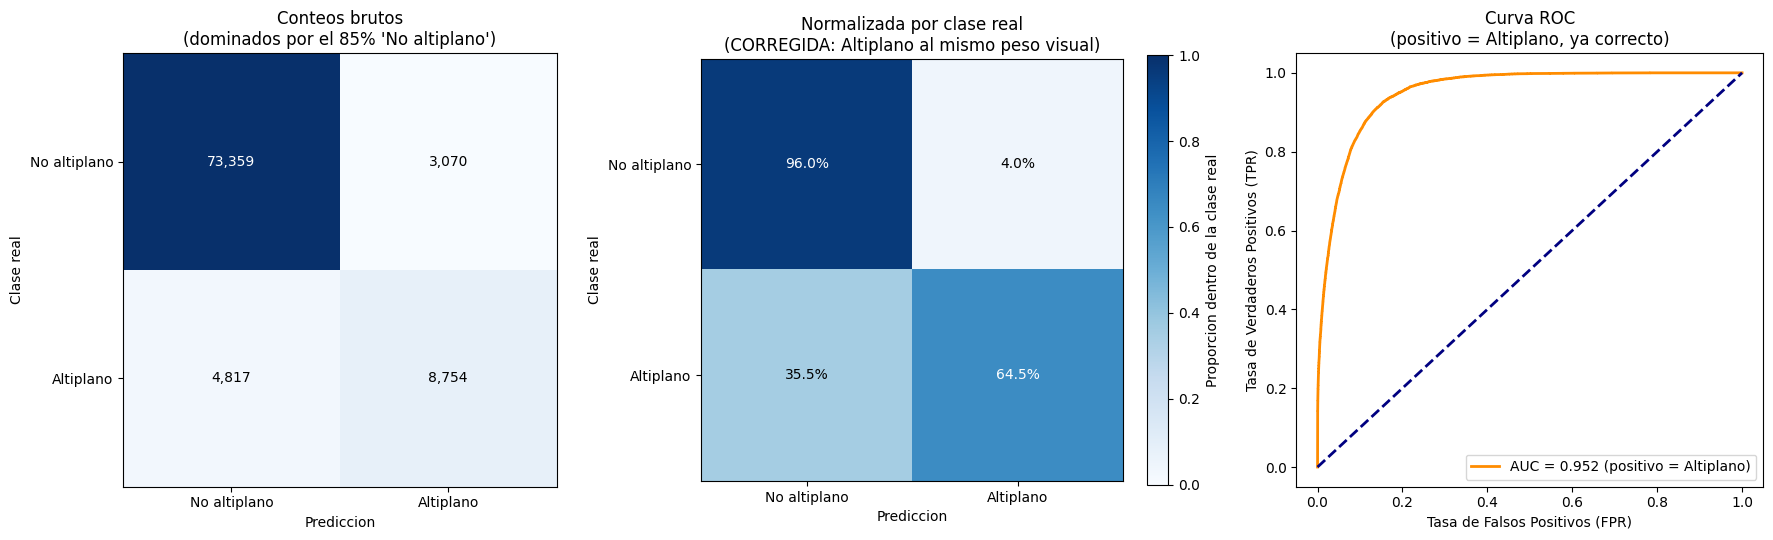


Recall Altiplano (fila 2 normalizada): 64.5%
Recall No altiplano (fila 1 normalizada): 96.0%
AUC-ROC (positivo=Altiplano): 0.9522

Figura corregida guardada en: C:\Users\MSI\Desktop\Universidad\Analisis_Geoespacial\Imagenes\13_matriz_confusion_roc_corregida.png
TIEMPO TOTAL: 11.6 s


In [5]:
etiquetas = ["No altiplano", "Altiplano"]
matriz_conf_norm = matriz_conf.astype(float) / matriz_conf.sum(axis=1, keepdims=True)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel 1: conteos brutos (igual que la figura original, como referencia)
im1 = ax1.imshow(matriz_conf, cmap="Blues")
for i in range(2):
    for j in range(2):
        color = "white" if matriz_conf[i, j] > matriz_conf.max() * 0.5 else "black"
        ax1.text(j, i, f"{matriz_conf[i, j]:,}", ha="center", va="center", color=color)
ax1.set_xticks([0, 1]); ax1.set_xticklabels(etiquetas)
ax1.set_yticks([0, 1]); ax1.set_yticklabels(etiquetas)
ax1.set_xlabel("Prediccion"); ax1.set_ylabel("Clase real")
ax1.set_title("Conteos brutos\n(dominados por el 85% 'No altiplano')")

# Panel 2: normalizada por fila -- CORRECCION: Altiplano visible en su propia escala
im2 = ax2.imshow(matriz_conf_norm, cmap="Blues", vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        color = "white" if matriz_conf_norm[i, j] > 0.5 else "black"
        ax2.text(j, i, f"{matriz_conf_norm[i, j]*100:.1f}%", ha="center", va="center", color=color)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(etiquetas)
ax2.set_yticks([0, 1]); ax2.set_yticklabels(etiquetas)
ax2.set_xlabel("Prediccion"); ax2.set_ylabel("Clase real")
ax2.set_title("Normalizada por clase real\n(CORREGIDA: Altiplano al mismo peso visual)")
plt.colorbar(im2, ax=ax2, fraction=0.046, label="Proporcion dentro de la clase real")

# Panel 3: curva ROC (sin cambios -- ya calculada correctamente para Altiplano)
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax3.plot(fpr, tpr, color="darkorange", lw=2, label=f"AUC = {auc:.3f} (positivo = Altiplano)")
ax3.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
ax3.set_xlabel("Tasa de Falsos Positivos (FPR)")
ax3.set_ylabel("Tasa de Verdaderos Positivos (TPR)")
ax3.set_title("Curva ROC\n(positivo = Altiplano, ya correcto)")
ax3.legend(loc="lower right")

plt.tight_layout()
plt.savefig(f"{CARPETA_IMAGENES}\\13_matriz_confusion_roc_corregida.png", dpi=150)
plt.show()

print(f"\nRecall Altiplano (fila 2 normalizada): {matriz_conf_norm[1,1]*100:.1f}%")
print(f"Recall No altiplano (fila 1 normalizada): {matriz_conf_norm[0,0]*100:.1f}%")
print(f"AUC-ROC (positivo=Altiplano): {auc:.4f}")
print(f"\nFigura corregida guardada en: {CARPETA_IMAGENES}\\13_matriz_confusion_roc_corregida.png")
print(f"TIEMPO TOTAL: {time.time()-t_inicio:.1f} s")